# Wine dataset overview with matplotlib

This notebook loads the `sklearn` wine dataset and creates a few static matplotlib visualizations.

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt

wine = load_wine(as_frame=True)
df = wine.frame.copy()
df['target_name'] = df['target'].map(dict(enumerate(wine.target_names)))
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [2]:
summary = df.groupby('target_name')[['alcohol', 'malic_acid', 'color_intensity']].mean().round(2)
summary

,alcohol,malic_acid,color_intensity
target_name,,,
class_0,13.74,2.01,5.53
class_1,12.28,1.93,3.09
class_2,13.15,3.33,7.40


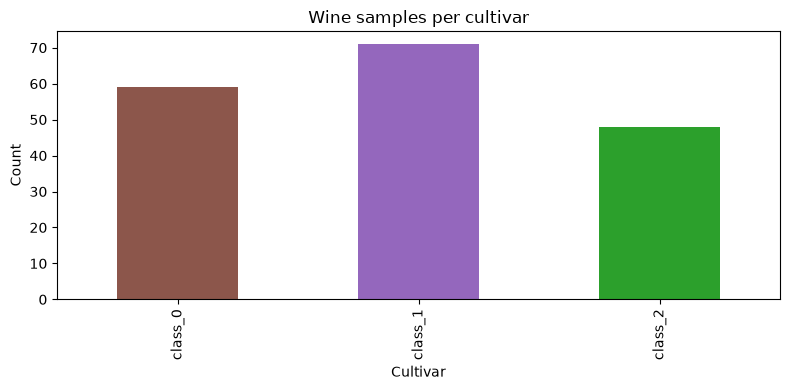

In [3]:
class_counts = df['target_name'].value_counts().sort_index()
ax = class_counts.plot(kind='bar', color=['#8c564b', '#9467bd', '#2ca02c'], figsize=(8, 4))
ax.set_title('Wine samples per cultivar')
ax.set_xlabel('Cultivar')
ax.set_ylabel('Count')
plt.tight_layout()

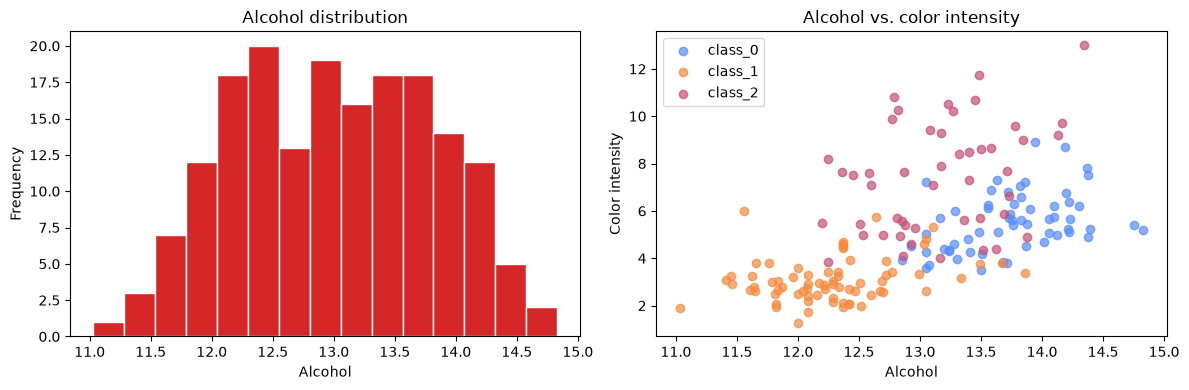

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['alcohol'], bins=15, color='#d62728', edgecolor='white')
axes[0].set_title('Alcohol distribution')
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Frequency')

for target_name, subset in df.groupby('target_name'):
    axes[1].scatter(subset['alcohol'], subset['color_intensity'], label=target_name, alpha=0.7)
axes[1].set_title('Alcohol vs. color intensity')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Color intensity')
axes[1].legend()
plt.tight_layout()